In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# 1. Open the spreadsheet

In [2]:
# 1. Define the file path and sheet name
file_path = 'graph_ingredients.xlsx'
sheet = 'Edge List_Expanded'

# 2. Load data into a DataFrame

In [3]:
# 2. Read the Excel file into a DataFrame
df = pd.read_excel(file_path, sheet_name=sheet)

# 3. View the first few rows to confirm it worked
print(df.head())

df['Weight'] = pd.to_numeric(df['Weight'], errors='coerce').fillna(0)

    Source                 Target  Weight  \
0     Root                Younger     0.4   
1     Root               Same age     0.4   
2     Root                  Older     0.2   
3  Younger  Younger (child's gen)     0.5   
4  Younger     Younger (same gen)     0.5   

                                             Note  \
0  Branch probability = 0.4 (Estimated frequency)   
1  Branch probability = 0.4 (Estimated frequency)   
2  Branch probability = 0.2 (Estimated frequency)   
3         Branch probability = 0.5 (Evenly split)   
4         Branch probability = 0.5 (Evenly split)   

                          Cumulative Logic  
0                   1.0 (Root) * 0.4 = 0.4  
1                   1.0 (Root) * 0.4 = 0.4  
2                   1.0 (Root) * 0.2 = 0.2  
3  0.4 (Incoming from Younger) * 0.5 = 0.2  
4  0.4 (Incoming from Younger) * 0.5 = 0.2  


# 3. Create the Graph

In [4]:
# 3. Create the Graph
G = nx.from_pandas_edgelist(df, source='Source', target='Target', edge_attr='Weight')

# 4. Visualize

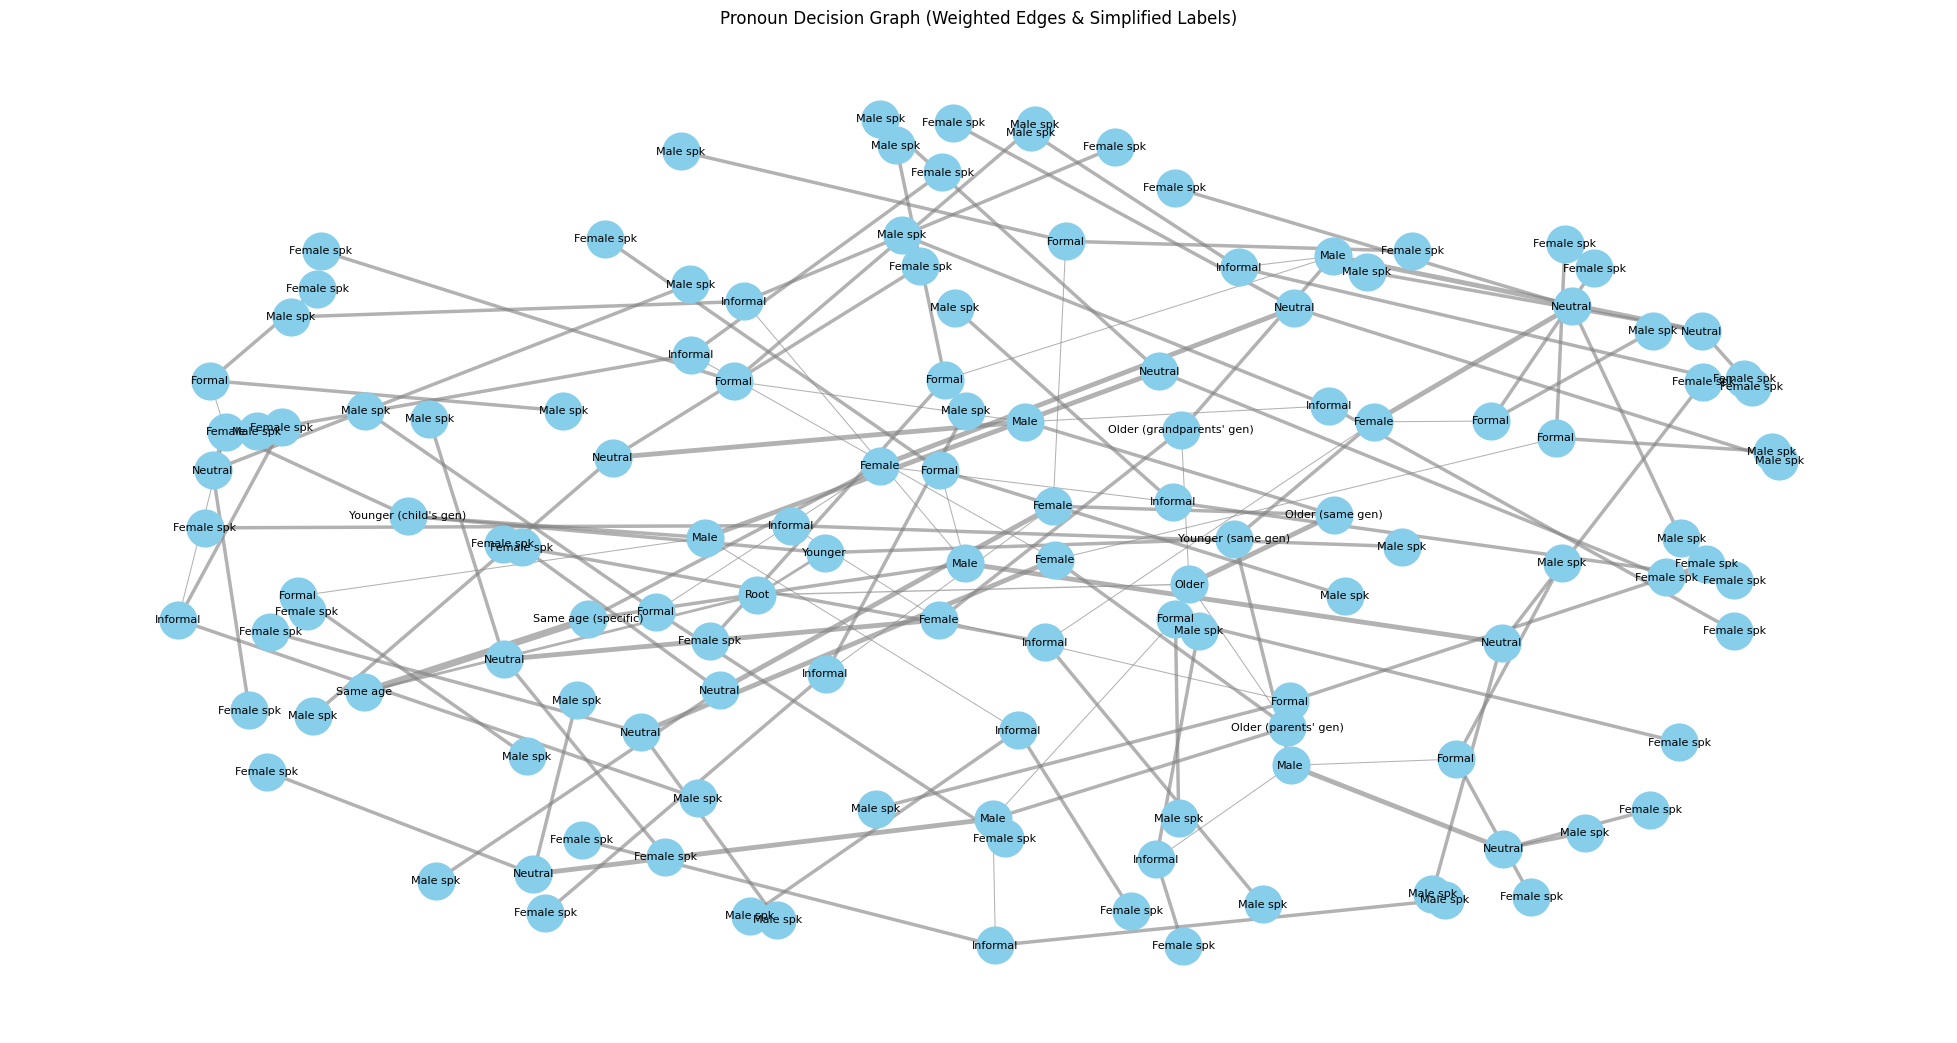

In [5]:
plt.figure(figsize=(25, 13)) # Increased height slightly for better spacing
pos = nx.spring_layout(G, k=0.5) # Layout for nodes

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=700, node_color='skyblue')

# Draw edges with thickness based on Weight
weights = [G[u][v]['Weight'] * 5 for u, v in G.edges()] # Scaling weight for visibility
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.6)

# --- MODIFICATION: Create simplified labels ---
# This splits the string by " - " and takes the very last element
# Example: "Younger - Male - Neutral" becomes just "Neutral"
short_labels = {node: str(node).split(' - ')[-1] for node in G.nodes()}

# Draw labels using the new 'labels' parameter
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, font_family='sans-serif')

plt.title("Pronoun Decision Graph (Weighted Edges & Simplified Labels)")
plt.axis('off')
plt.show()

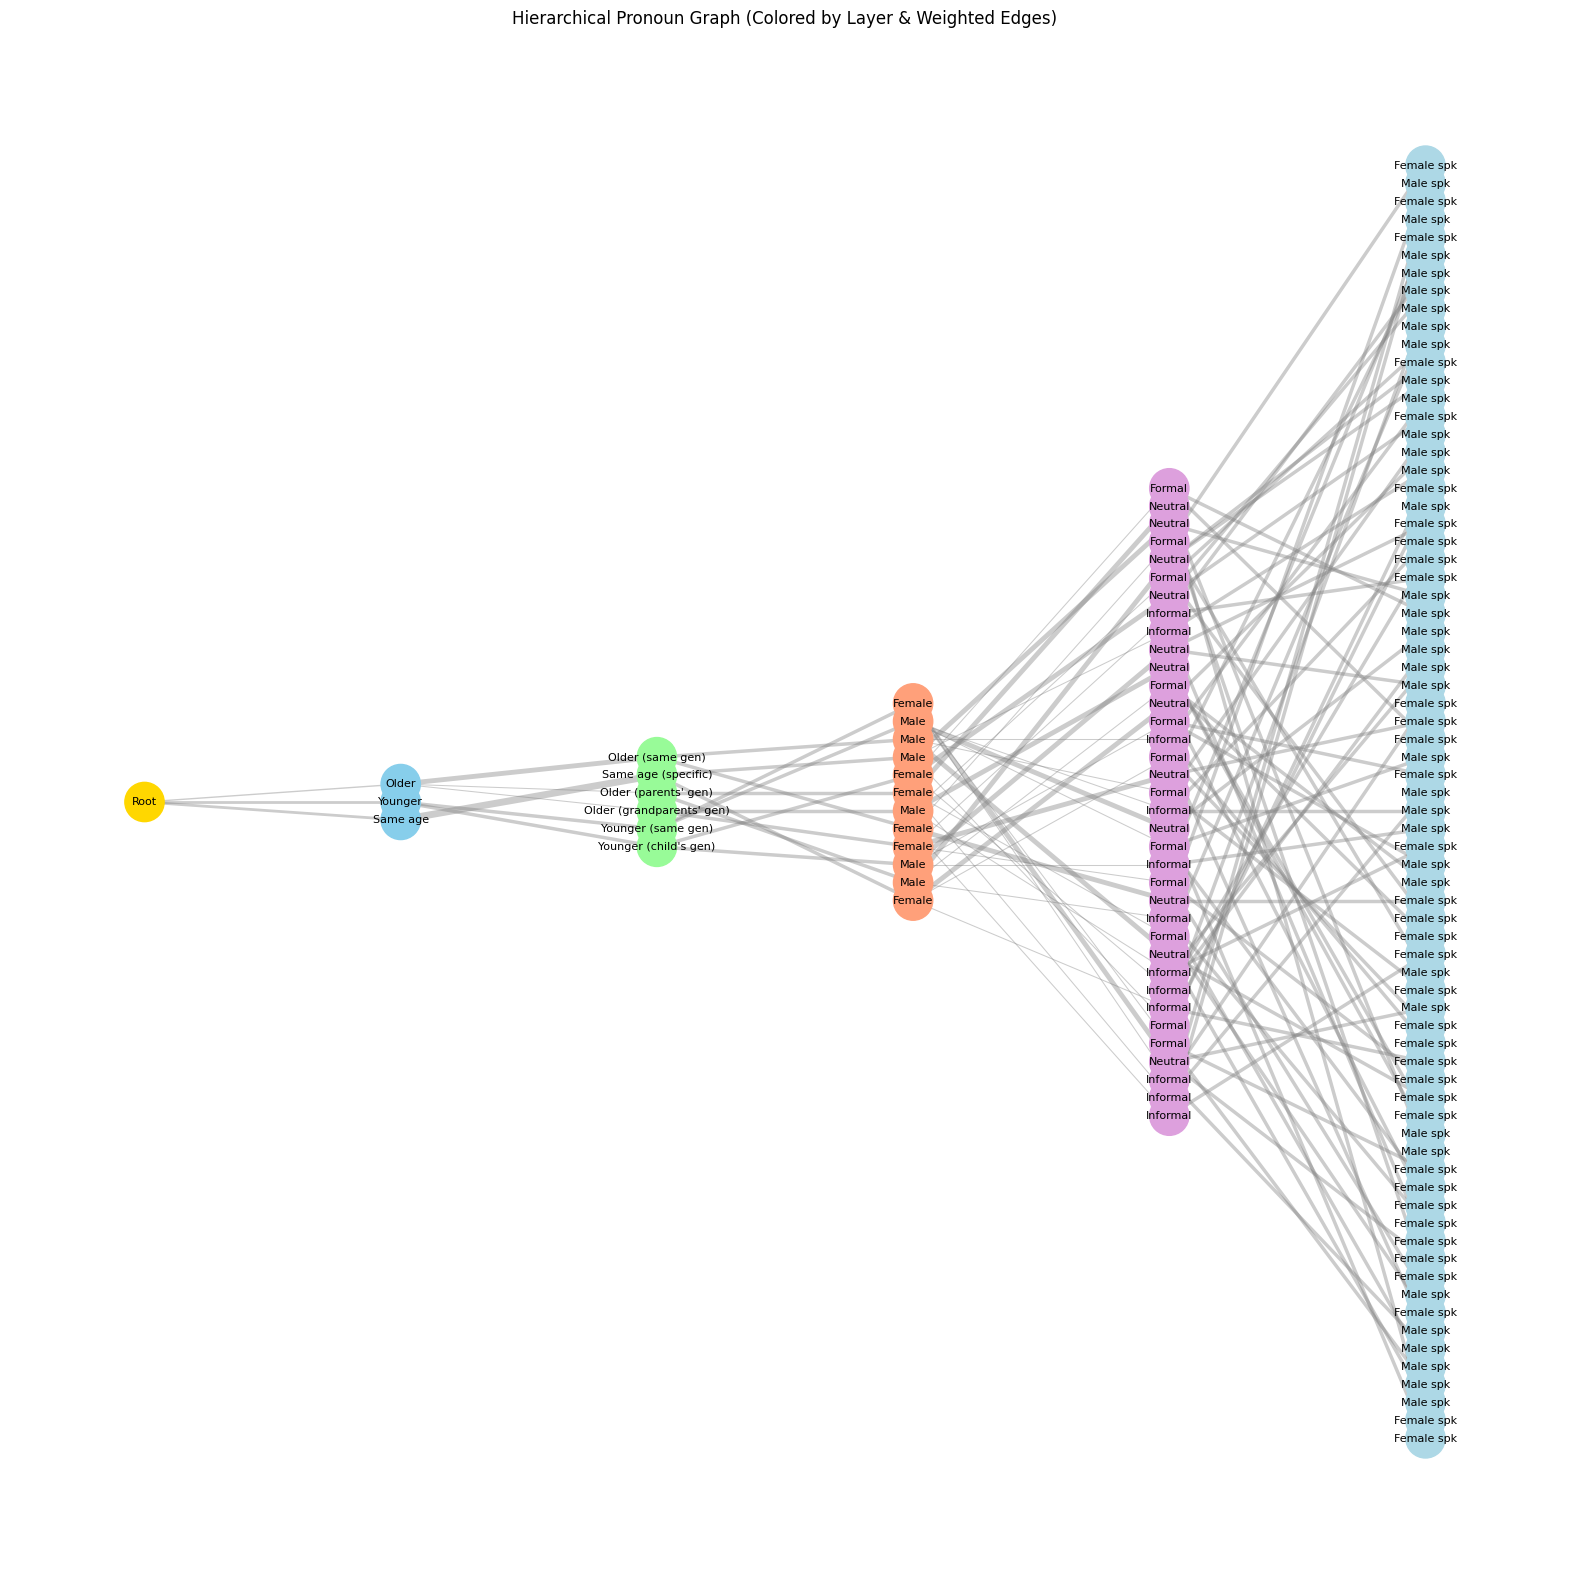

In [6]:
# 1. Calculate depth from Root to determine layers (if not already done)
depths = nx.single_source_shortest_path_length(G, 'Root')
for node, depth in depths.items():
    G.nodes[node]['layer'] = depth

# 2. Define your color palette for each layer
# Layer 0: Root, Layer 1: Age, Layer 2: Gender, Layer 3: Social, Layer 4: Speaker
layer_colors = {
    0: '#FFD700', # Gold
    1: '#87CEEB', # Sky Blue
    2: '#98FB98', # Pale Green
    3: '#FFA07A', # Light Salmon
    4: '#DDA0DD', # Plum
    5: '#ADD8E6'  # Light Blue - Added for layer 5
}

# 3. Create a list of colors for each node in the order they appear in G.nodes()
node_colors = [layer_colors[G.nodes[n]['layer']] for n in G.nodes()]

# 4. Visualize
plt.figure(figsize=(20, 20))
# Use multipartite_layout for the hierarchical look
pos = nx.multipartite_layout(G, subset_key='layer')

# Draw nodes with the new node_colors list
nx.draw_networkx_nodes(G, pos, node_size=800, node_color=node_colors)

# Draw edges with thickness based on Weight
weights = [G.get_edge_data(u, v, default={}).get('Weight', 0) * 5 for u, v in G.edges()] # Added .get('Weight', 0) to handle missing 'Weight' attribute
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.4)

# Create simplified labels
short_labels = {node: str(node).split(' - ')[-1] for node in G.nodes()}

# Draw labels
nx.draw_networkx_labels(G, pos, labels=short_labels, font_size=8, font_family='sans-serif')

plt.title("Hierarchical Pronoun Graph (Colored by Layer & Weighted Edges)")
plt.axis('off')
plt.show()

# Based on everything above

Tree version - Removed after defense

In [7]:
# import pandas as pd
# import networkx as nx
# import uuid
# import json
# from networkx.readwrite import json_graph

# G_schema = nx.DiGraph() 
# db_df = pd.read_excel("db_pronouns_social-adressing_v1.xlsx", sheet_name="input_nodes")
# db_df = db_df[~db_df['adressing relation'].str.contains("child", na=False)] 

# db_df['language'] = db_df['language'].fillna('Unknown').astype(str).str.strip().str.title()

# def map_game_nodes(row):
#     relation = str(row['adressing relation']).lower()
#     note = str(row['any note?']).lower()
    
#     # 🌟 NEW: Layer 1 - Broad Age (Easy Level)
#     if "younger" in relation: broad_age = "Younger"
#     elif "same age" in relation: broad_age = "Same Age"
#     else: broad_age = "Older" # Covers older same gen, parents, and grandparents
        
#     # 🌟 NEW: Layer 2 - Specific Generation (Medium Level)
#     if "senior" in relation or "grandparent" in relation: specific_age = "Grandparents' gen"
#     elif "middle-age" in relation or "parents" in relation: specific_age = "Parents' gen"
#     elif "older" in relation: specific_age = "Older (same gen)"
#     elif "younger" in relation: specific_age = "Younger (same gen)"
#     else: specific_age = "Exactly same age"
        
#     # Layer 3: Gender (Medium Level)
#     addr_options = ["Male", "Female"]
#     if "you as male" in note or "bhai" in note or "uncle" in relation or "uncle" in note or ("male" in note and "female" not in note): 
#         addr_options = ["Male"]
#     elif "you as female" in note or "baji" in note or "apa" in note or "aunt" in relation or "aunty" in note or "khala" in note or ("female" in note): 
#         addr_options = ["Female"]

#     # Layer 4: Context (Hard Level)
#     social_options = ["Neutral"]
#     if "casual" in note or "informal" in note: social_options = ["Informal"]
#     elif "formal" in note or "polite" in note or "respect" in note: social_options = ["Formal"]
        
#     # Layer 5: Speaker Gender (Minor)
#     spk_options = ["Male spk", "Female spk"]
#     if "i/me as male" in note: spk_options = ["Male spk"]
#     elif "i/me as female" in note: spk_options = ["Female spk"]

#     paths = []
#     for addr in addr_options:
#         for social in social_options:
#             for spk in spk_options:
#                 # 🌟 Updated to a 5-Layer Path!
#                 paths.append(f"{broad_age} - {specific_age} - {addr} - {social} - {spk}")
#     return paths

# for index, row in db_df.iterrows():
#     target_paths = map_game_nodes(row)
#     for path in target_paths:
#         G_schema.add_node(path, type="schema_path", layer=5)

# G_plugged = G_schema.copy()
# for index, row in db_df.iterrows():
#     target_paths = map_game_nodes(row)
#     instance_id = f"Instance_{uuid.uuid4().hex[:6]}"
#     term_i = str(row['terms (i/me)']).strip() if pd.notna(row['terms (i/me)']) else ""
#     term_you = str(row['terms (you)']).strip() if pd.notna(row['terms (you)']) else ""
#     lang = row['language']
    
#     if term_i == "" and term_you == "": continue
#     if "no word" in term_i.lower() or "no word" in term_you.lower(): continue
        
#     G_plugged.add_node(instance_id, type="instance", language=lang, term_i=term_i, term_you=term_you)
#     for path in target_paths:
#         G_plugged.add_edge(path, instance_id, type="HAS_PRONOUN")

# # 🌟 NEW: Expanded Penalty Rules reflecting your exact hierarchy!
# penalty_rules = {
#     "Broad Age": 5,          # Easy Mode (Critical)
#     "Specific Gen": 4,       # Medium Mode (Major-High)
#     "Addressee": 3,          # Medium Mode (Major-Low)
#     "Context": 2,            # Hard Mode (Moderate)
#     "Speaker": 1             # Minor Awkwardness
# }

# G_plugged.graph['scoring_rules'] = penalty_rules
# G_plugged.graph['max_penalty'] = sum(penalty_rules.values())

# plugged_data = json_graph.node_link_data(G_plugged)
# with open("graph_export/graph_plugged_data.json", "w", encoding="utf-8") as f:
#     json.dump(plugged_data, f, ensure_ascii=False, indent=4)
# print("✅ Saved 'graph_plugged_data.json' with new 5-Layer Difficulty Paths!")

In [8]:
# import matplotlib.pyplot as plt
# import networkx as nx
# import matplotlib.patches as mpatches

# plt.figure(figsize=(20, 20)) # Increased size for better readability

# # 1. Generate Custom Labels (Replace "Instance_XYZ" with actual words)
# custom_labels = {}
# for n, attr in G_plugged.nodes(data=True):
#     if attr.get('type') == 'instance':
#         # Show Language + Terms
#         lang = attr.get('language', 'Unknown')
#         term_i = attr.get('term_i', '')
#         term_you = attr.get('term_you', '')
#         custom_labels[n] = f"{lang}\n{term_i} / {term_you}"
#     else:
#         # For schema paths, just split it by newlines so it fits in the circle
#         custom_labels[n] = n.replace(" - ", "\n")

# # 2. Set Colors by Language
# language_colors = {
#     'Vietnamese': '#ff9999',  # Red-ish
#     'Urdu': '#99ff99',        # Green-ish
#     'Nepali': '#99ccff',      # Blue-ish
#     'Schema': '#e0e0e0'       # Gray for the logical paths
# }

# node_colors = []
# for n, attr in G_plugged.nodes(data=True):
#     if attr.get('type') == 'schema_path':
#         node_colors.append(language_colors['Schema'])
#     else:
#         lang = attr.get('language', 'Unknown')
#         node_colors.append(language_colors.get(lang, '#ffcc99'))

# # 3. Dynamic Sizing based on connections
# node_sizes = [3000 if G_plugged.nodes[n]['type'] == 'instance' else 1500 for n in G_plugged.nodes()]

# # 4. Generate Layout (Increased k to push nodes further apart)
# pos = nx.spring_layout(G_plugged, k=0.9, iterations=100, seed=42)

# # --- Draw the Graph ---
# # Draw nodes
# nx.draw_networkx_nodes(G_plugged, pos, node_size=node_sizes, node_color=node_colors, edgecolors='white', linewidths=2)

# # Draw edges
# nx.draw_networkx_edges(G_plugged, pos, edge_color='#cccccc', alpha=0.6, width=1.5)

# # Draw labels
# nx.draw_networkx_labels(G_plugged, pos, labels=custom_labels, font_size=8, font_weight='bold')

# # 5. Add a Legend
# legend_handles = [mpatches.Patch(color=color, label=lang) for lang, color in language_colors.items()]
# plt.legend(handles=legend_handles, loc='upper right', fontsize=12, title="Node Types", title_fontsize=14)

# plt.title("Pronoun Knowledge Graph Mapping", fontsize=20, fontweight='bold', pad=20)
# plt.axis('off')
# plt.tight_layout()
# plt.show()

In [9]:
# import pandas as pd
# import itertools

# # Create a list to hold our data
# nodes_data = []
# edges_data = []
# confusion_data = []

# # ==========================================
# # 1. EXPORT NODES (Paths and Pronoun Instances)
# # ==========================================
# for node, attr in G_plugged.nodes(data=True):
#     nodes_data.append({
#         'Node ID': node,
#         'Node Type': attr.get('type', ''),
#         'Language': attr.get('language', 'N/A'),
#         'Term (I/Me)': attr.get('term_i', 'N/A'),
#         'Term (You)': attr.get('term_you', 'N/A')
#     })

# nodes_df = pd.DataFrame(nodes_data)
# nodes_df.to_csv('graph_export/artifacts/nodes.csv', index=False, encoding='utf-8-sig')
# print(f"✅ Saved 'nodes.csv' ({len(nodes_df)} rows)")


# # ==========================================
# # 2. EXPORT EDGES (The Connections)
# # ==========================================
# for source, target, attr in G_plugged.edges(data=True):
#     edges_data.append({
#         'Source (Path)': source,
#         'Target (Instance)': target,
#         'Relationship': attr.get('type', 'HAS_PRONOUN')
#     })

# edges_df = pd.DataFrame(edges_data)
# edges_df.to_csv('graph_export/artifacts/edges.csv', index=False, encoding='utf-8-sig')
# print(f"✅ Saved 'edges.csv' ({len(edges_df)} edges)")


# # ==========================================
# # 3. EXPORT CONFUSION MATRIX (Now with Penalty Weights!)
# # ==========================================
# # Define the Cultural Penalty Weights
# penalty_rules = {
#     "Age Group": {"score": 5, "severity": "Critical Error 🚨"},
#     "Addressee Gender": {"score": 3, "severity": "Major Error 🔴"},
#     "Social Context": {"score": 2, "severity": "Moderate Error 🟠"},
#     "Speaker Gender": {"score": 1, "severity": "Minor Error 🟡"}
# }

# instance_nodes = [n for n, attr in G_plugged.nodes(data=True) if attr.get('type') == 'instance']

# langs_dict = {}
# for n in instance_nodes:
#     lang = G_plugged.nodes[n]['language']
#     if lang not in langs_dict:
#         langs_dict[lang] = []
#     langs_dict[lang].append(n)

# for lang, instances in langs_dict.items():
#     for inst1, inst2 in itertools.combinations(instances, 2):
#         data1 = G_plugged.nodes[inst1]
#         data2 = G_plugged.nodes[inst2]
        
#         if data1.get('term_i') == data2.get('term_i') and data1.get('term_you') == data2.get('term_you'):
#             continue
            
#         paths1 = list(G_plugged.predecessors(inst1))
#         paths2 = list(G_plugged.predecessors(inst2))
        
#         max_matches = -1
#         best_p1, best_p2 = "", ""
#         diff_feature = ""
#         penalty_score = 0
#         severity_label = ""
        
#         for p1 in paths1:
#             for p2 in paths2:
#                 parts1 = p1.split(' - ')
#                 parts2 = p2.split(' - ')
                
#                 matches = sum(1 for f1, f2 in zip(parts1, parts2) if f1 == f2)
                
#                 if matches > max_matches:
#                     max_matches = matches
#                     best_p1 = p1
#                     best_p2 = p2
                    
#                     if matches == 3:
#                         diff_idx = [i for i, (f1, f2) in enumerate(zip(parts1, parts2)) if f1 != f2][0]
#                         feature_names = ["Age Group", "Addressee Gender", "Social Context", "Speaker Gender"]
#                         diff_feature = feature_names[diff_idx]
                        
#                         # Apply the weight rules!
#                         penalty_score = penalty_rules[diff_feature]["score"]
#                         severity_label = penalty_rules[diff_feature]["severity"]
                        
#         if max_matches == 3:
#             confusion_data.append({
#                 'Language': lang,
#                 'Pronoun Pair A (I/You)': f"{data1.get('term_i')} / {data1.get('term_you')}",
#                 'Pronoun Pair B (I/You)': f"{data2.get('term_i')} / {data2.get('term_you')}",
#                 'What causes confusion?': f"Changes {diff_feature} ONLY",
#                 'Penalty Score': penalty_score,
#                 'Severity Level': severity_label,
#                 'Context A': best_p1,
#                 'Context B': best_p2
#             })

# confusion_df = pd.DataFrame(confusion_data)

# # Sort by Language first, then by Penalty Score (Highest to Lowest) so the worst mistakes are at the top!
# confusion_df = confusion_df.sort_values(by=['Language', 'Penalty Score'], ascending=[True, False])
# confusion_df.to_csv('graph_export/artifacts/confusion.csv', index=False, encoding='utf-8-sig')
# print(f"✅ Saved 'confusion.csv' ({len(confusion_df)} high-confusion pairs found!)")

# **AFTER DEFENSE**

In [14]:
import pandas as pd
import networkx as nx
import uuid
import json
import matplotlib.pyplot as plt
from networkx.readwrite import json_graph

print("1. Reading Database...")
db_df = pd.read_excel("db_pronouns_social-adressing_v1.xlsx", sheet_name="input_nodes")
db_df = db_df[~db_df['adressing relation'].str.contains("child", na=False)] 
db_df['language'] = db_df['language'].fillna('Unknown').astype(str).str.strip().str.title()

G_plugged = nx.DiGraph() 
attribute_nodes = set()

def add_attribute_node(graph, node_id, category):
    if node_id not in attribute_nodes:
        graph.add_node(node_id, type="attribute", category=category)
        attribute_nodes.add(node_id)

def process_and_build_graph(row):
    relation = str(row['adressing relation']).lower()
    note = str(row['any note?']).lower()
    
    # Layer Definitions
    if "younger" in relation: broad_age = "Younger"
    elif "same age" in relation: broad_age = "Same Age"
    else: broad_age = "Older" 
        
    if "senior" in relation or "grandparent" in relation: specific_age = "Grandparents' gen"
    elif "middle-age" in relation or "parents" in relation: specific_age = "Parents' gen"
    elif "older" in relation: specific_age = "Older (same gen)"
    elif "younger" in relation: specific_age = "Younger (same gen)"
    else: specific_age = "Exactly same age"
        
    addr_options = ["Male", "Female"]
    if "you as male" in note or "bhai" in note or "uncle" in relation or "uncle" in note or ("male" in note and "female" not in note): 
        addr_options = ["Male"]
    elif "you as female" in note or "baji" in note or "apa" in note or "aunt" in relation or "aunty" in note or "khala" in note or ("female" in note): 
        addr_options = ["Female"]

    social_options = ["Neutral"]
    if "casual" in note or "informal" in note: social_options = ["Informal"]
    elif "formal" in note or "polite" in note or "respect" in note: social_options = ["Formal"]
        
    spk_options = ["Male spk", "Female spk"]
    if "i/me as male" in note: spk_options = ["Male spk"]
    elif "i/me as female" in note: spk_options = ["Female spk"]

    paths = []
    for addr in addr_options:
        for social in social_options:
            for spk in spk_options:
                path_str = f"{broad_age} - {specific_age} - {addr} - {social} - {spk}"
                paths.append(path_str)
                
                # Add the central Scenario Node
                G_plugged.add_node(path_str, type="schema_path")
                
                # Register the 5 deduplicated attribute nodes globally
                add_attribute_node(G_plugged, f"Age: {broad_age}", "Broad Age")
                add_attribute_node(G_plugged, f"Gen: {specific_age}", "Specific Gen")
                add_attribute_node(G_plugged, f"Target: {addr}", "Addressee Gender")
                add_attribute_node(G_plugged, f"Context: {social}", "Social Context")
                add_attribute_node(G_plugged, f"Spk: {spk}", "Speaker Gender")
                
                # Create Semantic Web connections
                G_plugged.add_edge(path_str, f"Age: {broad_age}", type="HAS_BROAD_AGE")
                G_plugged.add_edge(path_str, f"Gen: {specific_age}", type="HAS_SPECIFIC_GEN")
                G_plugged.add_edge(path_str, f"Target: {addr}", type="HAS_TARGET")
                G_plugged.add_edge(path_str, f"Context: {social}", type="HAS_CONTEXT")
                G_plugged.add_edge(path_str, f"Spk: {spk}", type="HAS_SPEAKER")
                
    return paths

print("2. Building Instances & Applying Penalty Rules...")
for index, row in db_df.iterrows():
    target_paths = process_and_build_graph(row)
    
    instance_id = f"Instance_{uuid.uuid4().hex[:6]}"
    term_i = str(row['terms (i/me)']).strip() if pd.notna(row['terms (i/me)']) else ""
    term_you = str(row['terms (you)']).strip() if pd.notna(row['terms (you)']) else ""
    lang = row['language']
    
    if term_i == "" and term_you == "": continue
    if "no word" in term_i.lower() or "no word" in term_you.lower(): continue
        
    label = f"{lang}: {term_i}/{term_you}"
    G_plugged.add_node(instance_id, type="instance", language=lang, term_i=term_i, term_you=term_you, label=label)
    
    for path in target_paths:
        G_plugged.add_edge(path, instance_id, type="HAS_PRONOUN")

# 🌟 REQUIREMENT 1: EMBEDDING PENALTY RULES
penalty_rules = { "Broad Age": 5, "Specific Gen": 4, "Addressee": 3, "Context": 2, "Speaker": 1 }
G_plugged.graph['scoring_rules'] = penalty_rules
G_plugged.graph['max_penalty'] = sum(penalty_rules.values())

print("3. Exporting Core Artifacts (CSV & JSON)...")
# 🌟 REQUIREMENT 2: EXPORT ARTIFACTS
nodes_export = [{"id": n, **data} for n, data in G_plugged.nodes(data=True)]
pd.DataFrame(nodes_export).to_csv("graph_export/artifacts/nodes.csv", index=False)

edges_export = [{"source": u, "target": v, **data} for u, v, data in G_plugged.edges(data=True)]
pd.DataFrame(edges_export).to_csv("graph_export/artifacts/edges.csv", index=False)

confusions_data = [
    {"Mismatch_Layer": "Broad Age", "Penalty_Points": 5, "Severity": "Critical Error"},
    {"Mismatch_Layer": "Specific Gen", "Penalty_Points": 4, "Severity": "Major Generational Mistake"},
    {"Mismatch_Layer": "Addressee Gender", "Penalty_Points": 3, "Severity": "Major Error"},
    {"Mismatch_Layer": "Social Context", "Penalty_Points": 2, "Severity": "Moderate Register Misalignment"},
    {"Mismatch_Layer": "Speaker Gender", "Penalty_Points": 1, "Severity": "Minor Awkwardness"}
]
pd.DataFrame(confusions_data).to_csv("graph_export/artifacts/confusion.csv", index=False)

plugged_data = json_graph.node_link_data(G_plugged)
with open("graph_export/graph_data.js", "w", encoding="utf-8") as f:
    f.write("var myGraphData = ")
    json.dump(plugged_data, f, ensure_ascii=False, indent=4)
    f.write(";")

print("4. Generating Static Visualizations...")
plt.figure(figsize=(18, 14))
color_map, node_sizes = [], []
for node, data in G_plugged.nodes(data=True):
    node_type = data.get("type", "")
    if node_type == "attribute":
        color_map.append("#bdc3c7")
        node_sizes.append(800)
    elif node_type == "instance":
        color_map.append("#54a0ff")
        node_sizes.append(400)
    else:
        color_map.append("#ecf0f1")
        node_sizes.append(50)

pos = nx.spring_layout(G_plugged, k=0.5, iterations=30, seed=42)
nx.draw_networkx_nodes(G_plugged, pos, node_color=color_map, node_size=node_sizes, edgecolors='white')
nx.draw_networkx_edges(G_plugged, pos, alpha=0.1, edge_color="gray", arrows=False)
plt.axis('off')
plt.savefig("semantic_graph.png", dpi=150, bbox_inches='tight')
plt.close()

1. Reading Database...
2. Building Instances & Applying Penalty Rules...
3. Exporting Core Artifacts (CSV & JSON)...
4. Generating Static Visualizations...


In [15]:
print("5. Generating HTML Vis.js Dashboard...")
# 🌟 THIS IS THE MISSING PIECE FOR VIS.JS
nodes_data, edges_data = [], []

for node, data in G_plugged.nodes(data=True):
    node_type = data.get("type", "")
    vis_node = {"id": node}
    
    if node_type == "attribute":
        cat = data.get("category", "")
        color = "#bdc3c7"
        if cat == "Broad Age": color = "#ff9f43"
        elif cat == "Specific Gen": color = "#ee5253"
        elif cat == "Addressee Gender": color = "#1dd1a1"
        elif cat == "Social Context": color = "#5f27cd"
        else: color = "#ff9ff3"
        
        vis_node.update({"label": node, "title": f"Category: {cat}", "color": color, "size": 28, "shape": "dot", "font": {"color": "#2c3e50", "size": 14, "bold": True}})
        
    elif node_type == "instance":
        lang = data.get("language", "")
        vis_node.update({"label": data.get("label", node), "title": f"Language: {lang}", "color": "#54a0ff", "size": 22, "shape": "box", "font": {"color": "#ffffff", "size": 12}})
        
    elif node_type == "schema_path":
        vis_node.update({"label": " ", "title": node, "color": "#ecf0f1", "size": 8, "shape": "dot"})
        
    nodes_data.append(vis_node)

for u, v, data in G_plugged.edges(data=True):
    edges_data.append({"from": u, "to": v, "title": data.get("type", ""), "color": {"color": "#bdc3c7", "opacity": 0.4}})

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>Semantic Pronoun Web</title>
    <script type="text/javascript" src="https://unpkg.com/vis-network/standalone/umd/vis-network.min.js"></script>
    <style type="text/css">
        body, html {{ margin: 0; padding: 0; height: 100%; font-family: sans-serif; background-color: #f4f7f6; }}
        #mynetwork {{ width: 100%; height: 100vh; border: none; }}
        .legend {{ position: absolute; top: 20px; left: 20px; background: rgba(255, 255, 255, 0.9); padding: 15px; border-radius: 8px; box-shadow: 0 4px 10px rgba(0,0,0,0.1); z-index: 1000; }}
        .legend h3 {{ margin: 0 0 10px 0; font-size: 16px; color: #2c3e50; }}
        .legend-item {{ display: flex; align-items: center; margin-bottom: 6px; font-size: 13px; color: #34495e; font-weight: bold; }}
        .color-box {{ width: 14px; height: 14px; border-radius: 50%; margin-right: 8px; display: inline-block; }}
        .box-shape {{ border-radius: 3px; }}
    </style>
</head>
<body>
    <div class="legend">
        <h3>Graph Legend</h3>
        <div class="legend-item"><span class="color-box" style="background: #ff9f43;"></span> Broad Age</div>
        <div class="legend-item"><span class="color-box" style="background: #ee5253;"></span> Specific Generation</div>
        <div class="legend-item"><span class="color-box" style="background: #1dd1a1;"></span> Addressee Gender</div>
        <div class="legend-item"><span class="color-box" style="background: #5f27cd;"></span> Social Context</div>
        <div class="legend-item"><span class="color-box" style="background: #ff9ff3;"></span> Speaker Gender</div>
        <div class="legend-item"><span class="color-box box-shape" style="background: #54a0ff;"></span> Pronoun (Instances)</div>
        <div class="legend-item"><span class="color-box" style="background: #ecf0f1; border: 1px solid #bdc3c7;"></span> Hidden Scenario Hubs</div>
        <div style="margin-top: 10px; font-size: 11px; color: #7f8c8d; font-weight: normal;">* Scroll to zoom, drag to pan.<br>* Hover over nodes for details.</div>
    </div>
    <div id="mynetwork"></div>
    <script type="text/javascript">
        var nodes = new vis.DataSet({json.dumps(nodes_data)});
        var edges = new vis.DataSet({json.dumps(edges_data)});
        var network = new vis.Network(document.getElementById('mynetwork'), {{nodes: nodes, edges: edges}}, {{
            physics: {{
                forceAtlas2Based: {{ gravitationalConstant: -60, centralGravity: 0.01, springLength: 100, springConstant: 0.08 }},
                maxVelocity: 50, solver: 'forceAtlas2Based', timestep: 0.35, stabilization: {{ iterations: 150 }}
            }},
            nodes: {{ borderWidth: 2, borderWidthSelected: 4 }},
            edges: {{ smooth: {{ type: 'continuous' }} }}
        }});
    </script>
</body>
</html>
"""

with open("interactive_graph.html", "w", encoding="utf-8") as f:
    f.write(html_content)

print("✅ Finished! Graph built, UI rules embedded, CSV artifacts exported, and HTML generated perfectly.")

5. Generating HTML Vis.js Dashboard...
✅ Finished! Graph built, UI rules embedded, CSV artifacts exported, and HTML generated perfectly.


### 1. The Core Math: The 5-Layer Penalties

* **Layer 1: Broad Age** (e.g., Younger vs. Older) ➡️ **5 Points** *(Critical Error)*
* **Layer 2: Specific Gen** (e.g., Parents vs. Grandparents) ➡️ **4 Points** *(Major Generational Mistake)*
* **Layer 3: Addressee Gender** (e.g., Uncle vs. Aunt) ➡️ **3 Points** *(Major Mistake)*
* **Layer 4: Social Context** (e.g., Formal vs. Casual) ➡️ **2 Points** *(Moderate Mistake)*
* **Layer 5: Speaker Gender** (e.g., "I" male vs "I" female) ➡️ **1 Point** *(Minor Awkwardness)*

### 2. The Gameplay: The "Bounty" System

* The player starts the round with **0 points**.
* There are 5 questions in the queue.
* Every question is born with a **Bounty of 20 Potential Points** (5 questions × 20 points = 100 Max Score).
* If the player gets the question right on the first try, they win the full **+20 points** for their score.

### 3. The Levels: Adaptive Distractors

The game uses the player's position in the queue to actively change the difficulty of the wrong answers (distractors):

* **🟢 Warm-Up (Questions 1 & 2):** The game intentionally picks wrong answers with the *highest penalties* (e.g., mixing up a Grandparent with a Child). It's easy for the player to spot the wrong answers.
* **🟡 Intermediate (Question 3):** The game mixes it up randomly, leaning heavily on Specific Generation or Gender changes.
* **🔴 Advanced (Questions 4 & 5):** The game actively hunts for wrong answers with the *lowest penalties*. It forces the player to look at two pronouns that have the exact same age and gender, but differ only by **Social Context** (Formal vs Informal).

### 4. What Happens When They Make a Mistake?

If the player clicks the wrong answer, they do not lose their total score. Instead, the game penalizes the *Bounty* for that specific question:

1. It calculates the penalty of the mistake (e.g., wrong Addressee Gender = 3 points).
2. It multiplies the penalty by 2 (3 × 2 = 6).
3. It subtracts that from the question's bounty (20 - 6 = **14 points left**).
4. The question is sent to the back of the line and labeled **"Review Mode"**.
5. When the question comes back around, the maximum the player can win for it is now 14 points instead of 20. *(Note: The game will never drop a bounty below 5 points, so the player is always rewarded for eventually getting it right).*

### 5. The Final Grade

At the end of the round, the player receives a Cultural Fluency Score out of 100 based on how many points they successfully captured:

* **90 – 100:** 🏆 Outstanding! (Near-native cultural fluency).
* **70 – 89:** 👍 Great job! (Solid grasp on social nuances, maybe just a few minor context slip-ups).
* **40 – 69:** 📚 Good effort! (Still learning the generational rules, likely made some medium/major errors).
* **0 – 39:** 🌱 Keep practicing! (Made several Critical/Broad Age mistakes).

This system is brilliant because it never punishes a player for trying, it automatically adjusts its own difficulty based on the language, and it gives precise, targeted feedback on *why* an answer is culturally inappropriate!